## CNN regression

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['figure.dpi'] = 150

In [2]:
# Check available hardware
import torch
if torch.cuda.is_available():
    print(f'GPU is available, using GPU {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
elif torch.mps.is_available():
    print(f'Apple Metal Performance Shaders framework is available, using {torch.device("mps")}')
    device = torch.device('mps')
else:
    print(f'Hardware acceleration not available, using CPU')
    device = torch.device('cpu')

GPU is available, using GPU Tesla T4


## Dataset: UTK Face

See here: https://susanqq.github.io/UTKFace/

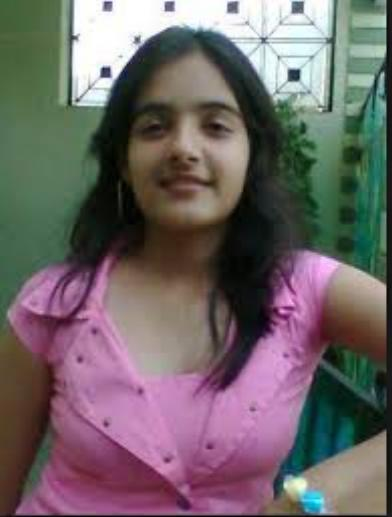

In [5]:
import os
from PIL import Image

path = os.path.expanduser('~/data10/utk-face/UTKface_inthewild')
image_files = [f for f in os.listdir(path) if f.endswith('.jpg')]

img = Image.open(os.path.join(path, image_files[1]))
img

In [6]:
from torch.utils.data import Dataset
import os
class UTKFaceDataset(Dataset):
    """ Custom dataset class to load in UTK Face dataset elements
        Files have the name format [age]_[gender]_[race]_[date&time].jpg
    """
    def __init__(self,
                 root=os.path.expanduser('~/data10/utk-face/UTKface_inthewild'), 
                 transform=None):
        self.root = root
        self.transform = transform

        self.image_files = [f for f in os.listdir(root) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_file = self.image_files[idx]
        image = Image.open(os.path.join(self.root, image_file))
        if image.mode != 'RGB':
            image = image.convert('RGB')

        if self.transform:
            image = self.transform(image)

        age = int(image_file.split('_')[0])
        return image, torch.tensor(age, dtype=torch.float32)

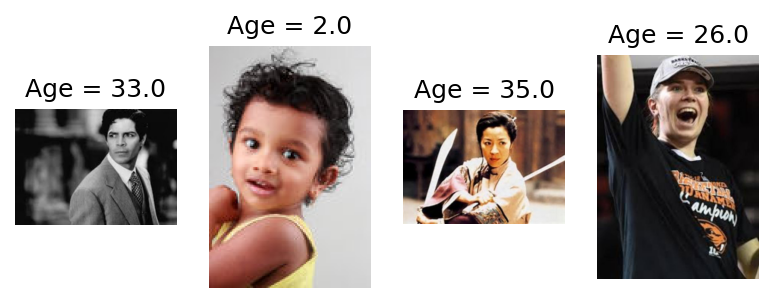

In [7]:
dataset = UTKFaceDataset()

fig, ax = plt.subplots(1, 4)
for ii in range(4):
    idx = np.random.choice(len(dataset))
    img, age = dataset[idx]
    ax[ii].imshow(img)
    ax[ii].set_title(f'Age = {age:.1f}')
    ax[ii].axis('off')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


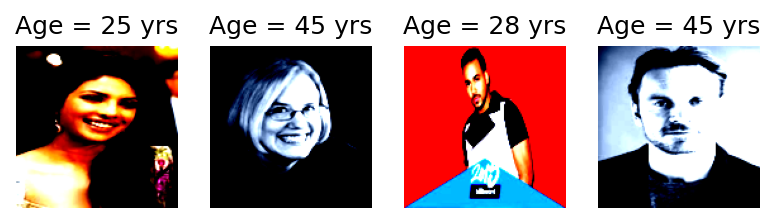

In [10]:
from torchvision.transforms import v2

# ImageNet normalization
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])
norm = v2.Normalize(mean=imagenet_mean, std=imagenet_std)

transform = v2.Compose([
    # Transforms go here
    v2.ToImage(),
    v2.Resize([128, 128]),
    v2.ToDtype(torch.float32, scale=True),
    norm,
])
dataset = UTKFaceDataset(transform=transform)

fig, ax = plt.subplots(1, 4)
for ii in range(4):
    idx = np.random.choice(len(dataset))
    img, age = dataset[idx]
    # img = denormalize(img)
    ax[ii].imshow(img.permute(1, 2, 0))
    ax[ii].set_title(f'Age = {age:.0f} yrs')
    ax[ii].axis('off')

In [11]:
from torch.utils.data import random_split
train_dataset, val_dataset, test_dataset = random_split(dataset, lengths=[0.6, 0.2, 0.2])
print(len(train_dataset), len(val_dataset), len(test_dataset))

14464 4821 4821


## CNN implementation

This is a harder problem so we're going to build a bigger neural network. Two tools will come in handy:

- Residual (or skip) connections
- Batch normalization

In [20]:
import torch.nn as nn
import torch.nn.functional as F

class ResBlock(nn.Module):
    def __init__(self, c_in, c_out, **conv_kwargs):
        super().__init__()        
        self.conv1 = nn.Conv2d(c_in, c_out, **conv_kwargs)
        self.bn1 = nn.BatchNorm2d(c_out)
        
        self.conv2 = nn.Conv2d(c_out, c_out, **conv_kwargs)
        self.bn2 = nn.BatchNorm2d(c_out)

        if c_in == c_out:
            self.proj = nn.Identity()
        else:
            # Projection layer to match channel dimensions
            self.proj = nn.Conv2d(c_in, c_out, kernel_size=1) 

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + self.proj(x) # Skip connection
        out = F.relu(out)

        return out

class CNN_Regression(nn.Module):
    def __init__(self):
        super().__init__()

        # Let's do a list of stages, each containing some CNN layers
        # After each stage, we'll do a MaxPool and downsample
        self.stages = nn.ModuleList()

        # Input data is [B, 3, 128, 128]
        # First stage projects data onto a large feature map
        self.stages.append(
            nn.Sequential(
                nn.Conv2d(3, 32, kernel_size=3, padding='same'),
                nn.BatchNorm2d(32),
                nn.ReLU()
            )
        )
        # First stage output is [B, 32, 64, 64]
        
        # Let's just stack a bunch of Residual blocks in each stage
        in_channels = 32
        for ii in range(4):
            stage = []
            stage.append(ResBlock(in_channels, 2*in_channels, kernel_size=3, padding='same'))
            in_channels *= 2
            stage.append(ResBlock(in_channels, in_channels, kernel_size=3, padding='same'))
            # stage.append(ResBlock(in_channels, in_channels, kernel_size=3, padding='same'))
            self.stages.append(nn.Sequential(*stage))

        # I have 32 * 2^4 = 32 * 16 = 512 channels
        # I have dowsampled the spatial dimensions by a factor of 16
        # Final stage output is [B, 512, 4, 4]

        # I have a lot of options in what I do here
        # Global average pooling, big linear layer, some compromise to that?
        # Suppose I flatten this into a big FC layer?
        # I'm going to do global average pooling, because it has fewer parameters
        
        self.dropout = nn.Dropout(p=0.5)
        self.fc = nn.Linear(512, 1)

    def forward(self, x):
        # x has shape [B, 3, H, W]
        # Iterate through my nn.ModuleList of stages
        for stage in self.stages:
            x = stage(x)
            x = F.max_pool2d(x, 2)

        # Spatial average pooling
        x = x.mean(dim=(-2, -1))

        # Spatial max pooling
        # x = x.amax(dim=(-2, -1))

        # Flattening (most costly)
        # x = x.reshape([-1, 512*4*4])
        
        x = self.dropout(x)
        x = self.fc(x)
        x = F.relu(x) # Apply relu to ensure non-negative age predictions
        return x   

In [21]:
model = CNN_Regression().to(device)

# Ensure we can make a prediction with this model, no issues
img, age = dataset[0]
pred = model(img.to(device)[None])
print(f'Model makes prediction which is {pred}')

# How many weights are there now?
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'CNN has {num_trainable_params} trainable parameters')

model

Model makes prediction which is tensor([[0.]], device='cuda:0', grad_fn=<ReluBackward0>)
CNN has 11155073 trainable parameters


CNN_Regression(
  (stages): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): ResBlock(
        (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (proj): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
      )
      (1): ResBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    

## Model training

In [22]:
def train(model, 
          optimizer, 
          loss_func, 
          train_dataset, 
          val_dataset, 
          batch_size=32, 
          num_epochs=10, 
          num_workers=4, 
          scheduler=None,
          early_stop=10):
    model = model.to(device)

    # Build training and validation loaders
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True, pin_memory=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False, pin_memory=True)

    train_loss, val_loss = [], []
    train_mad, val_mad = [], [] # Tracking mean absolute deviation in units of years

    for epoch in range(num_epochs):
        model.train()
        train_loss_ = 0.
        train_mad_ = 0.
        for xb, yb in tqdm(train_loader, leave=False):
            # Send data to device
            xb = xb.to(device)
            yb = yb.to(device).unsqueeze(1)

            # Make a prediction, compute the loss
            y_pred = model(xb)
            loss = loss_func(y_pred, yb)

            # Backpropagate, apply gradients, reset for next pass
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Log loss and metrics
            train_loss_ += loss.item() * yb.shape[0]
            train_mad_ += F.l1_loss(y_pred, yb, reduction='sum').item()
            
        train_loss.append(train_loss_ / len(train_loader.dataset))
        train_mad.append(train_mad_ / len(train_loader.dataset))

        model.eval()
        with torch.no_grad():
            val_loss_ = 0.
            val_mad_ = 0.
            for xb, yb in tqdm(val_loader, leave=False):
                # Send data to device
                xb = xb.to(device)
                yb = yb.to(device).unsqueeze(1)

                # Make a prediction, compute the loss
                y_pred = model(xb)
                loss = loss_func(y_pred, yb)

                # Log loss and metrics
                val_loss_ += loss.item() * yb.shape[0]
                val_mad_ += F.l1_loss(y_pred, yb, reduction='sum').item()

            val_loss.append(val_loss_ / len(val_loader.dataset))
            val_mad.append(val_mad_ / len(val_loader.dataset))

        print(f'Epoch {epoch+1} | '
              f'Train loss { train_loss[-1]:.3f} | '
              f'Train MAD { train_mad[-1]:.3f} years | '
              f'Val loss { val_loss[-1]:.3f} | '
              f'Val MAD { val_mad[-1]:.3f} years '
        )

        # Learning rate scheduling
        if scheduler is not None:
            scheduler.step()

        # Early stopping
        best_epoch = np.argmin(val_loss)
        if epoch - best_epoch > early_stop:
            print(f'Early stopping at Epoch {epoch+1}')

    return train_loss, train_mad, val_loss, val_mad


In [24]:
from tqdm.notebook import tqdm

model = CNN_Regression()
loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loss, train_mad, val_loss, val_mad = train(
    model, optimizer, loss, train_dataset, val_dataset,
    batch_size=32, num_epochs=1, num_workers=8)

  0%|          | 0/452 [00:00<?, ?it/s]

  0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1 | Train loss 384.356 | Train MAD 15.081 years | Val loss 344.628 | Val MAD 14.654 years 


Let's run this script in the background while we move onto the next part

In [26]:
results = torch.load(os.path.expanduser('~/scr10/cnn_regression_results.pt'))
train_loss = results['train_loss']
train_mad = results['train_mad']
val_loss = results['val_loss']
val_mad = results['val_mad']

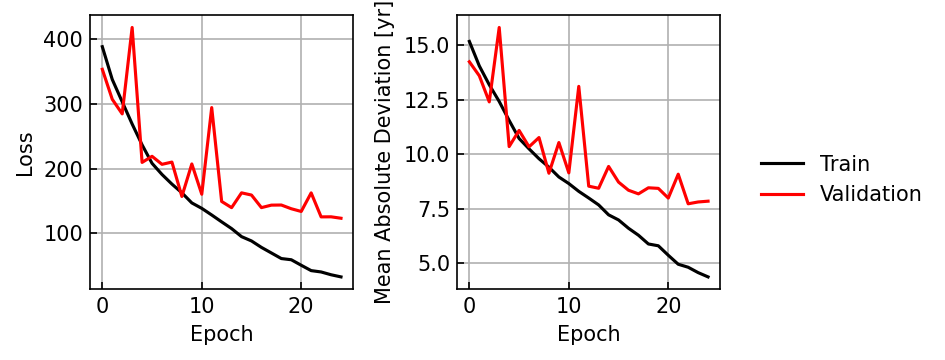

In [27]:
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(5, 2.5))

ax[0].plot(train_loss, color='black', label='Train')
ax[0].plot(val_loss, color='red', label='Validation')
ax[0].set(xlabel='Epoch', ylabel='Loss')

ax[1].plot(train_mad, color='black', label='Train')
ax[1].plot(val_mad, color='red', label='Validation')
ax[1].set(xlabel='Epoch', ylabel='Mean Absolute Deviation [yr]')

fig.legend(*ax[1].get_legend_handles_labels(), 
           loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)

plt.tight_layout()

## Evaluate on testing dataset

In [30]:
# Load the model back in
model = CNN_Regression()
model.load_state_dict(results['model_weights'])
model = model.to(device)

# Make sure we use the correct test dataset
test_dataset = torch.utils.data.Subset(dataset, results['test_indices'])
print(f'Test dataset has length {len(test_dataset)}')

Test dataset has length 4821


In [31]:
y_true, y_pred = [], []
model.eval()

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=8)
with torch.no_grad():
    for xb, yb in tqdm(test_loader):
        yp = model(xb.to(device))
        
        y_true.append(yb.numpy())
        y_pred.append(yp.squeeze().cpu().numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
print(y_true.shape, y_pred.shape)

  0%|          | 0/151 [00:00<?, ?it/s]

(4821,) (4821,)


Mean absolute difference: 7.9 yrs


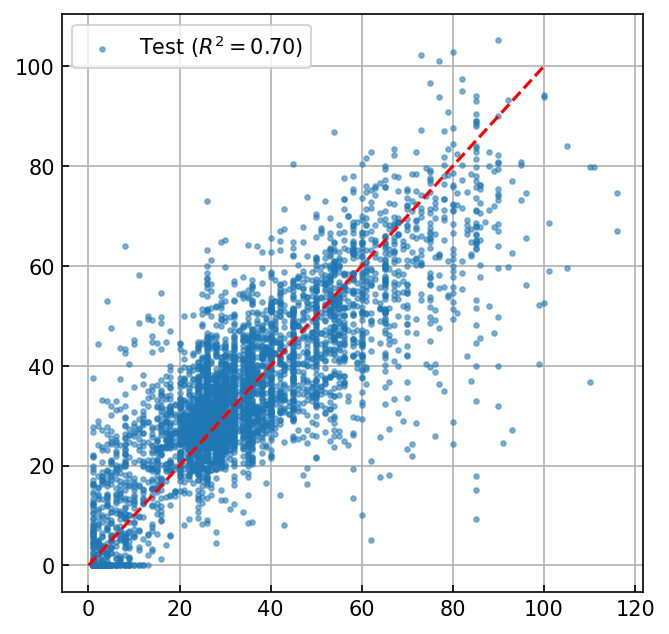

In [32]:
from sklearn.metrics import r2_score
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(y_true, y_pred, s=5, alpha=0.5, label=f'Test ($R^2 = {r2_score(y_true, y_pred):.2f}$)')
ax.plot([0,100], [0, 100], color='red', linestyle='--')
ax.legend();

print(f'Mean absolute difference: {np.mean(np.abs(y_true - y_pred)):.1f} yrs')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


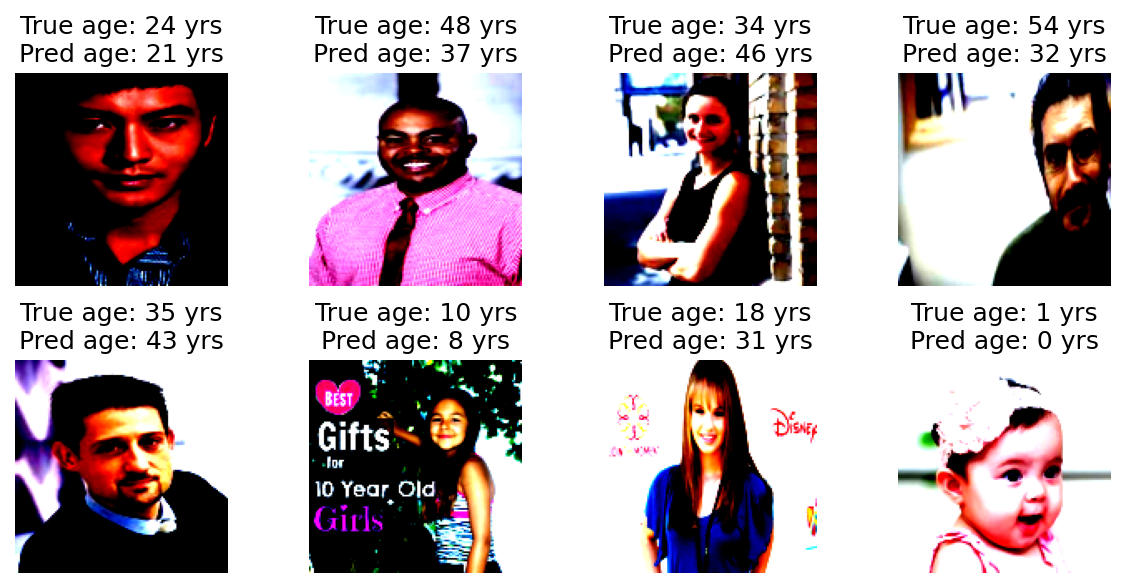

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for ii, ax in enumerate(axes.flatten()):
    x, y = test_dataset[np.random.choice(len(test_dataset))]
    with torch.no_grad():
        yp = model(x.to(device)[None]).squeeze().item()
    ax.imshow(x.cpu().permute(1, 2, 0)) #Denormalize images
    ax.set_title(f'True age: {y:.0f} yrs\nPred age: {yp:.0f} yrs')
    ax.axis('off')

plt.tight_layout()